In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os
from utils import *
import collections

##  3.1 Exploring the Dataset

First, download and extract this IMDb review dataset
in the path `./data/aclImdb`.

In [2]:
url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
data_dir = download_extract(url)

We'll start by loading the training data, which includes the reviews and their associated sentiment labels. After loading the data, we'll inspect a few examples to understand the format and content of the reviews and their corresponding sentiment labels. 

An example review might look like: "The movie was fantastic, and I thoroughly enjoyed it." The corresponding label for this positive review would be: 1. 

Conversely, a negative review might look like: "The plot was confusing, and the acting was subpar.". The corresponding label for this negative review would be: 0


In [3]:
train_data = read_imdb(data_dir, is_train=True)
print('# trainings:', len(train_data[0]))
for x, y in zip(train_data[0][:3], train_data[1][:3]):
    print('label:', y, 'review:', x[:150])

# trainings: 25000
label: 1 review: The year is 1896.Jeff Webster (James Stewart) doesn't like people.There's only one friend he's got and he's Ben Tatum (Walter Brennan), an old sympath
label: 1 review: I really enjoyed this -- I'm a big fan of movies that mess with your mind and leave you with a lot of questions and ideas to debate, and this was a st
label: 1 review: I must say I was impressed the cinematography was amazing, the frames close to perfection and the way he built up the tension around a subject that so


Please complete the following function.

When completing this function, consider the following:

- The function should take a text input and split it into individual word tokens (where each word is treated as a separate token).

In the case of word tokenization, a sentence like "The quick brown fox" would be split into individual tokens: ["The", "quick", "brown", "fox"].

In [4]:
def tokenize(lines):
    """Split text lines into word or character tokens."""
    ### START CODE HERE ###
    # Scope: Q4 tokenization - split each review into word tokens.
    return [line.split() for line in lines]
    ### END CODE HERE ###

Please plot the data distribution of the training data using a histogram. The x-axis should represent the length of each review, and the y-axis should indicate the number of corresponding samples. The x-axis will display the lengths of the reviews, while the y-axis will indicate the frequency or count of reviews with similar lengths.

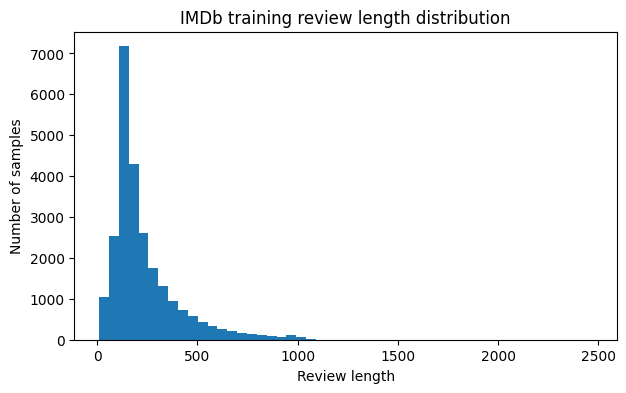

In [5]:
### START CODE HERE ###
# Scope: Q4 exploration - show the training review length distribution.
train_lengths = [len(tokens) for tokens in tokenize(train_data[0])]
plt.figure(figsize=(7, 4))
plt.hist(train_lengths, bins=50)
plt.xlabel('Review length')
plt.ylabel('Number of samples')
plt.title('IMDb training review length distribution')
plt.show()
### END CODE HERE ###

The **Vocab** class encapsulates the core operations related to vocabulary management, offering a convenient interface for working with text data in a structured manner.

In [6]:
class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs if freq >= min_freq])))
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self): 
        return self.token_to_idx['<unk>']


In [7]:
def truncate_pad(line, num_steps, padding_token):
    """Truncate or pad sequences."""
    if len(line) > num_steps:
        return line[:num_steps]  # Truncate
    return line + [padding_token] * (num_steps - len(line))  # Pad

Please complete the **load_data_imdb** function, which aims to facilitate the processing of the IMDb review dataset by providing a data loader and the vocabulary associated with the dataset. To achieve this, the function is expected to utilize predefined functions and classes to handle the dataset and its associated vocabulary. 

**Note: To process a minibatch of such reviews at each time, we set the length of each review to 500 with truncation and padding.**

In [8]:
def load_data_imdb(batch_size, num_steps=500):
    """Return data loader and the vocabulary of the IMDb review dataset."""
    # Scope: Q4 data loading - tokenize, index, pad/truncate, and batch IMDb.
    train_data = read_imdb(data_dir, is_train=True)
    test_data = read_imdb(data_dir, is_train=False)
    train_tokens = tokenize(train_data[0])
    test_tokens = tokenize(test_data[0])
    vocab = Vocab(train_tokens, min_freq=5, reserved_tokens=['<pad>'])

    train_features = torch.tensor(
        [truncate_pad(vocab[line], num_steps, vocab['<pad>'])
         for line in train_tokens])
    test_features = torch.tensor(
        [truncate_pad(vocab[line], num_steps, vocab['<pad>'])
         for line in test_tokens])
    train_labels = torch.tensor(train_data[1])
    test_labels = torch.tensor(test_data[1])

    train_loader = DataLoader(TensorDataset(train_features, train_labels),
                              batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(test_features, test_labels),
                             batch_size=batch_size)

    return train_loader, test_loader, vocab

In [9]:
batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

##  3.2 Using Bidirectional Recurrent Neural Networks for Sentiment Analysis

Please design a multilayer bidirectional RNN to process the IMDB dataset.

In [10]:
class BiRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens,
                 num_layers, **kwargs):
        ### START CODE HERE ###
        # Scope: Q4 BiRNN - define embedding, bidirectional LSTM, and classifier.
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.encoder = nn.LSTM(embed_size, num_hiddens, num_layers=num_layers,
                               bidirectional=True, batch_first=True)
        self.decoder = nn.Linear(4 * num_hiddens, 2)
        ### END CODE HERE ###

    def forward(self, inputs):
        ### START CODE HERE ###
        # Scope: Q4 BiRNN - classify from first and last encoded time steps.
        embeddings = self.embedding(inputs)
        outputs, _ = self.encoder(embeddings)
        encoding = torch.cat((outputs[:, 0, :], outputs[:, -1, :]), dim=1)
        return self.decoder(encoding)
        ### END CODE HERE ###

In [11]:
embed_size, num_hiddens, num_layers = 100, 100, 2
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)

Please initialize the weights of your predefined model.

In [12]:
def init_weights(module):
     ### START CODE HERE ###
     # Scope: Q4 initialization - initialize trainable linear/recurrent weights.
     if isinstance(module, nn.Linear):
         nn.init.xavier_uniform_(module.weight)
     if isinstance(module, nn.LSTM):
         for name, param in module.named_parameters():
             if 'weight' in name:
                 nn.init.xavier_uniform_(param)
     ### END CODE HERE ###  
net.apply(init_weights);

Next, we will load the pretrained 100-dimensional GloVe embeddings for tokens in the vocabulary. GloVe (Global Vectors for Word Representation) provides pre-defined dense vectors for a vast number of words in the English language, allowing for immediate utilization in various natural language processing (NLP) applications. The GloVe embeddings are available in different dimensions, such as 50-d, 100-d, 200-d, or 300-d vectors, with the dimensionality indicating the size of the vector representation for each word. To incorporate these pretrained embeddings, it's crucial to ensure consistency with the specified embed_size of 100. By leveraging the GloVe embeddings, we can enrich the model's understanding of the textual data and enhance its performance in NLP tasks.

You can downlaod the **glove.6b.100d** from https://nlp.stanford.edu/data/glove.6B.zip

In [13]:
# Scope: Q4 GloVe setup - download the pretrained vectors when missing.
if not os.path.exists('./data/glove.6B.100d.txt'):
    download_extract('https://nlp.stanford.edu/data/glove.6B.zip')
glove_embedding = TokenEmbedding('glove.6b.100d', './data')
embeds = glove_embedding[vocab.idx_to_token]

Please use these pretrained word vectors to represent tokens in the reviews and ensure not update these vectors during training.

In [14]:
### START CODE HERE ###
# Scope: Q4 BiRNN embeddings - load frozen pretrained GloVe vectors.
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False
### END CODE HERE ### 

Finally, we will proceed with training our network. Within the following function, you are expected to train your network and evaluate your model on the testing dataset. Additionally, you should generate visualizations depicting the training loss, training accuracy, and testing accuracy for each epoch.

In [15]:
def train(net, train_iter, test_iter, loss, trainer, num_epochs):
    ### START CODE HERE ###
    # Scope: Q4 training - train the network and plot epoch metrics.
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    net.to(device)
    train_losses, train_accs, test_accs = [], [], []

    for epoch in range(num_epochs):
        net.train()
        metric_loss, metric_correct, metric_count = 0.0, 0, 0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            trainer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y).mean()
            l.backward()
            trainer.step()

            metric_loss += l.item() * y.numel()
            metric_correct += (y_hat.argmax(dim=1) == y).sum().item()
            metric_count += y.numel()

        train_loss = metric_loss / metric_count
        train_acc = metric_correct / metric_count

        net.eval()
        test_correct, test_count = 0, 0
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                test_correct += (y_hat.argmax(dim=1) == y).sum().item()
                test_count += y.numel()
        test_acc = test_correct / test_count

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f'epoch {epoch + 1}: '
              f'loss {train_loss:.4f}, train acc {train_acc:.4f}, '
              f'test acc {test_acc:.4f}')

    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_losses, label='train loss')
    plt.plot(epochs, train_accs, label='train accuracy')
    plt.plot(epochs, test_accs, label='test accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    ### END CODE HERE ### 

epoch 1: loss 0.5706, train acc 0.6954, test acc 0.8097
epoch 2: loss 0.3935, train acc 0.8260, test acc 0.8251
epoch 3: loss 0.3541, train acc 0.8509, test acc 0.8171
epoch 4: loss 0.3154, train acc 0.8678, test acc 0.8541
epoch 5: loss 0.2966, train acc 0.8782, test acc 0.8567


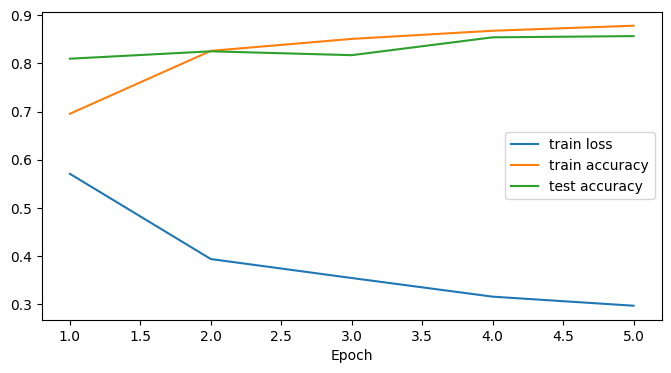

In [16]:
lr, num_epochs = 0.01, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train(net, train_iter, test_iter, loss, trainer, num_epochs)

##  3.3 Using TextCNN for Sentiment Analysis

Please design a TextCNN to process the IMDB dataset.

In [17]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_size, kernel_sizes, num_channels,
                 **kwargs):
        ### START CODE HERE ###
        # Scope: Q4 TextCNN - combine frozen/static and trainable embeddings.
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.constant_embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(0.5)
        self.decoder = nn.Linear(sum(num_channels), 2)
        self.relu = nn.ReLU()
        self.convs = nn.ModuleList()
        for channels, kernel_size in zip(num_channels, kernel_sizes):
            self.convs.append(nn.Conv1d(2 * embed_size, channels, kernel_size))
        ### END CODE HERE ### 

    def forward(self, inputs):
        ### START CODE HERE ###
        # Scope: Q4 TextCNN - apply temporal convolutions and max pooling.
        embeddings = torch.cat((
            self.embedding(inputs),
            self.constant_embedding(inputs)), dim=2)
        embeddings = embeddings.permute(0, 2, 1)
        convolved = [self.relu(conv(embeddings)) for conv in self.convs]
        encoding = torch.cat([
            torch.squeeze(F.max_pool1d(output, kernel_size=output.shape[-1]),
                          dim=-1)
            for output in convolved], dim=1)
        outputs = self.decoder(self.dropout(encoding))
        return outputs
        ### END CODE HERE ### 

Please initialize the weights of your predefined model.

In [18]:
def init_weights(module):
    ### START CODE HERE ###
    # Scope: Q4 TextCNN initialization - initialize classifier and conv weights.
    if isinstance(module, (nn.Linear, nn.Conv1d)):
        nn.init.xavier_uniform_(module.weight)
    ### END CODE HERE ### 

Next, we will load the pretrained 100-dimensional GloVe embeddings for tokens in the vocabulary. 

In [19]:
# Scope: Q4 GloVe setup - download the pretrained vectors when missing.
if not os.path.exists('./data/glove.6B.100d.txt'):
    download_extract('https://nlp.stanford.edu/data/glove.6B.zip')
glove_embedding = TokenEmbedding('glove.6b.100d', './data')
embeds = glove_embedding[vocab.idx_to_token]

Please use these pretrained word vectors to represent tokens in the reviews.

In [20]:
### START CODE HERE ###
# Scope: Q4 TextCNN embeddings - create the model and load GloVe weights.
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [100, 100, 100]
net = TextCNN(len(vocab), embed_size, kernel_sizes, nums_channels)
net.apply(init_weights);
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False
### END CODE HERE ### 

Finally, we will proceed with training our network.

In [21]:
# Scope: Q4 TextCNN setup - the model is ready for training.

epoch 1: loss 0.5803, train acc 0.7250, test acc 0.8347
epoch 2: loss 0.3594, train acc 0.8408, test acc 0.8580
epoch 3: loss 0.2541, train acc 0.8971, test acc 0.8635
epoch 4: loss 0.1576, train acc 0.9416, test acc 0.8649
epoch 5: loss 0.0858, train acc 0.9701, test acc 0.8699


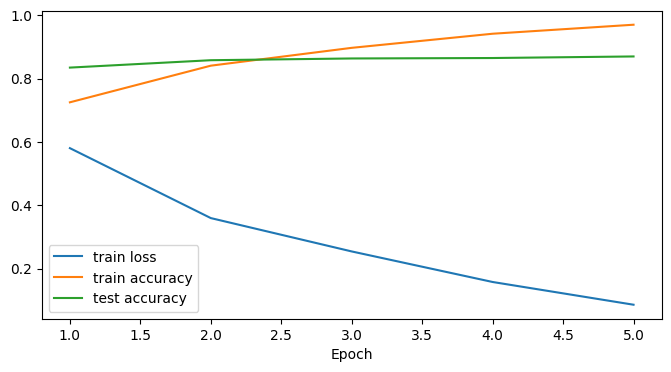

In [22]:
lr, num_epochs = 0.001, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train(net, train_iter, test_iter, loss, trainer, num_epochs)

Make the prediction for a text sequence.

In [23]:
def predict_sentiment(net, vocab, sequence):
    """Predict the sentiment of a text sequence."""
    ### START CODE HERE ###
    # Scope: Q4 prediction - convert a sentence to token ids and classify it.
    device = next(net.parameters()).device
    token_indices = vocab[tokenize([sequence])[0]]
    if hasattr(net, 'convs'):
        min_len = max(conv.kernel_size[0] for conv in net.convs)
        if len(token_indices) < min_len:
            token_indices += [vocab['<pad>']] * (min_len - len(token_indices))
    tokens = torch.tensor(token_indices, device=device).reshape(1, -1)
    net.eval()
    with torch.no_grad():
        label = torch.argmax(net(tokens), dim=1).item()
    return 'positive' if label == 1 else 'negative'
    ### END CODE HERE ### 

In [24]:
predict_sentiment(net, vocab, 'this movie is so great')

'positive'

In [25]:
predict_sentiment(net, vocab, 'this movie is so bad')

'negative'